# Lesson 4.3 - Convolutional Neural Networks & Computer Vision

## Learning Objectives
- Run a lightweight vision baseline experiment end-to-end.
- Understand practical trade-offs between classical and deep CV approaches.
- Use a reusable vision experiment checklist before deployment.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print('train_shape:', X_train.shape, 'test_shape:', X_test.shape)


train_shape: (1347, 64) test_shape: (450, 64)


## Quick Visual Inspection


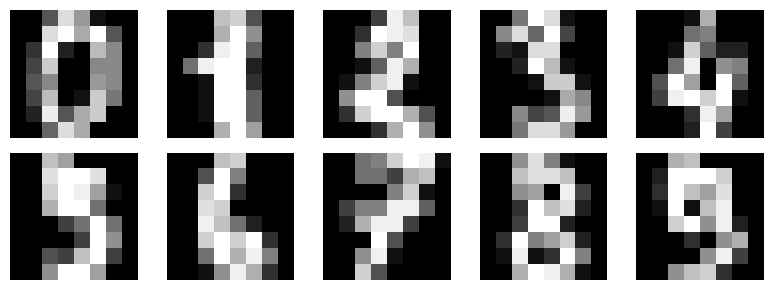

In [2]:
digits_images = load_digits().images
fig, axes = plt.subplots(2, 5, figsize=(8, 3))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(digits_images[idx], cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()


## Baseline Vision Classifier


In [3]:
baseline = LogisticRegression(max_iter=2000, random_state=SEED)
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)
print('accuracy:', round(accuracy_score(y_test, pred), 4))
print(classification_report(y_test, pred, digits=3))


accuracy: 0.9622
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        45
           1      0.896     0.935     0.915        46
           2      1.000     0.977     0.989        44
           3      0.979     1.000     0.989        46
           4      0.957     1.000     0.978        45
           5      0.978     0.978     0.978        46
           6      0.978     0.978     0.978        45
           7      1.000     0.978     0.989        45
           8      0.860     0.860     0.860        43
           9      0.976     0.911     0.943        45

    accuracy                          0.962       450
   macro avg      0.962     0.962     0.962       450
weighted avg      0.963     0.962     0.962       450



## Optional Tiny CNN (if PyTorch available)


In [4]:
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim

    class TinyCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(1, 8, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(8, 16, 3, padding=1),
                nn.ReLU(),
                nn.Flatten(),
                nn.Linear(16 * 4 * 4, 10),
            )

        def forward(self, x):
            return self.net(x)

    X_img = torch.tensor(load_digits().images, dtype=torch.float32).unsqueeze(1) / 16.0
    y_t = torch.tensor(load_digits().target, dtype=torch.long)

    idx = torch.randperm(len(X_img))
    train_idx = idx[:1300]
    test_idx = idx[1300:]

    model = TinyCNN()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-2)

    for _ in range(20):
        logits = model(X_img[train_idx])
        loss = criterion(logits, y_t[train_idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        preds = model(X_img[test_idx]).argmax(dim=1)
        acc = (preds == y_t[test_idx]).float().mean().item()
    print('tiny_cnn_accuracy:', round(acc, 4))
except Exception as e:
    print('PyTorch section skipped:', e)


tiny_cnn_accuracy: 0.9195


## Vision Experiment Checklist (Reusable)
- [ ] Deployment-like image conditions represented in evaluation.
- [ ] Per-class metrics reported, not just aggregate accuracy.
- [ ] Latency/throughput budget stated.
- [ ] Failure mode policy defined (low confidence, blur, occlusion).
- [ ] Monitoring plan for input drift exists.


## Case Studies & Exceptions
### Case 1: Manufacturing Defect Model Missed Rare Faults
High average accuracy hid poor recall on rare critical defects. Solution: class-weighting + targeted data collection + per-class monitoring.

### Case 2: Retail Camera Domain Shift
Model trained on clean images failed under in-store lighting variation. Solution: deployment-aware augmentation and periodic recalibration.

### Exception
For extremely constrained edge devices, simpler models with handcrafted features can still outperform heavier deep models on cost and latency.


## Interview Questions & Answers
1. **Q:** Why report per-class metrics in vision tasks?  
   **A:** Aggregate accuracy can hide failures on important classes.
2. **Q:** Why use transfer learning in CV?  
   **A:** It improves performance and speed when labeled data is limited.
3. **Q:** CNN vs logistic regression for images?  
   **A:** CNNs capture spatial structure better; logistic regression is a useful baseline.
4. **Q:** What is domain shift in CV?  
   **A:** Difference between training image distribution and deployment images.
5. **Q:** Why include latency in CV evaluation?  
   **A:** Many applications are real-time or near-real-time.
6. **Q:** How do you reduce inference cost?  
   **A:** Smaller backbones, quantization, batching strategy.
7. **Q:** What is a failure policy in vision systems?  
   **A:** Action taken when confidence is low or input quality is poor.
8. **Q:** Why keep a baseline model in CV projects?  
   **A:** To prove complexity gains are justified.
9. **Q:** What causes train-serve skew in CV?  
   **A:** Different preprocessing or augmentation behavior across environments.
10. **Q:** When might classical CV still be enough?  
   **A:** Controlled environments with narrow tasks and strict compute constraints.
